### 데이터 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

card_df = pd.read_csv('../data/credit_card_fraud_detection/creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


### 인자로 입력받은 DataFrame을 복사 한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환

In [2]:
from sklearn.model_selection import train_test_split

# 인자로 입력받은 DataFrame을 복사 한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

### 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수.

In [3]:
# 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수.
def get_train_test_dataset(df=None):
    # 인자로 입력된 DataFrame의 사전 데이터 가공이 완료된 복사 DataFrame 반환
    df_copy = get_preprocessed_df(df)

    # DataFrame의 맨 마지막 컬럼이 레이블, 나머지는 피처들
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]

    # train_test_split()으로 학습과 테스트 데이터 분할. stratify=y_target으로 Stratified 기반 분할
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    
    # 학습과 테스트 데이터 세트 반환
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

### 학습/테스트 데이터 레이블 비율

In [4]:
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


### get_clf_eval() : 오차행렬, 정확도, 정밀도, 재현도, F1 점수, AUC 를 출력하는 함수

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

### Estimator객체(model)와, 학습/테스트 데이터 세트를 입력 받아서 학습/예측/평가 수행.

In [4]:
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

### 랜덤 포레스트 학습 및 별도의 테스트 셋으로 예측 성능 평가

In [57]:
# 랜덤 포레스트 학습 및 별도의 테스트 셋으로 예측 성능 평가
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 결정 트리에서 사용한 get_human_dataset( )을 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

# 랜덤 포레스트 학습 및 별도의 테스트 셋으로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=42)

# 3장에서 사용한 get_model_train_eval() 함수를 이용하여 평가 수행.
get_model_train_eval(rf_clf, X_train, X_test, y_train, y_test)

# 랜덤 포레스트 정확도: 0.9994
# 오차 행렬
# [[85290     5]
#  [   43   105]]
# 정확도: 0.9994, 정밀도: 0.9545, 재현율: 0.7095,    F1: 0.8140, AUC:0.9407
# 정확도: 0.9994, 정밀도: 0.9386, 재현율: 0.7230,    F1: 0.8168, AUC:0.9475
# 정확도: 0.9994, 정밀도: 0.9386, 재현율: 0.7230,    F1: 0.8168, AUC:0.9475

오차 행렬
[[85290     5]
 [   43   105]]
정확도: 0.9994, 정밀도: 0.9545, 재현율: 0.7095,    F1: 0.8140, AUC:0.9407


### Amount 컬럼을 정규 분포로 변환 필요 => 다른 컬럼과 비교하기 위함

In [58]:
# Amount feature를 StandardScaler : 표준화, LR
from sklearn.preprocessing import StandardScaler
# 사이킷런의 StandardScaler를 이용하여 정규분포 형태로 Amount 피처값 변환하는 로직으로 수정.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    # 변환된 Amount를 Amount_Scaled로 피처명 변경후 DataFrame맨 앞 컬럼으로 입력
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기존 Time, Amount 피처 삭제
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

### 데이터 셋 분리, 예측 성능 측정

In [61]:

X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
X_train.head()
# get_model_train_eval(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

,Amount_Scaled,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
211605,-0.350471,-8.367621,7.402969,-5.114191,-2.966792,-0.985904,-1.660018,0.397816,1.008250,5.290976,...,-0.750795,3.589299,-0.557927,0.349087,0.301734,0.662330,1.145939,-0.012273,1.513736,0.669504
231628,-0.131456,-1.290662,0.764452,-0.169233,-1.688528,1.984718,-0.717210,1.667635,-0.228295,-0.959071,...,-0.059595,0.057620,0.138615,0.390374,-0.678774,0.292254,1.425865,0.265341,0.051405,0.103879
110643,-0.307251,-0.606860,0.233923,2.633361,-0.155762,-0.328850,-0.070593,0.173023,0.113394,0.680147,...,-1.003842,-0.129287,0.007393,0.265045,-0.040615,0.406088,-0.498823,0.121851,-0.046840,-0.087259
11478,-0.313249,1.374168,-0.330389,0.812971,-0.183112,-1.074771,-0.933788,-0.544238,-0.348237,0.614925,...,0.603330,0.078163,-0.134742,0.016793,0.002610,0.714527,0.536175,-0.307487,-0.003555,0.013024
243724,8.802588,-2.146505,-7.603113,-4.928224,1.449173,-2.083871,-0.984759,3.629816,-1.302973,-1.434148,...,-1.373723,4.009181,1.274986,-0.857670,-2.109682,0.169338,-0.322888,0.777822,-0.552258,0.304777


### 로그함수 : 큰 값일 수록 많이 줄이고 작은 값일 수록 적게 줄어든다.

In [63]:
# 로그함수 : 큰 값일 수록 많이 줄이고 작은 값일 수록 적게 줄어든다.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # 넘파이의 log1p( )를 이용하여 Amount를 로그 변환
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [64]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

# X_train.head()
get_model_train_eval(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

# 오차 행렬
# [[85288     7]
#  [   41   107]]
# 정확도: 0.9994, 정밀도: 0.9386, 재현율: 0.7230,    F1: 0.8168, AUC:0.9475

오차 행렬
[[85288     7]
 [   41   107]]
정확도: 0.9994, 정밀도: 0.9386, 재현율: 0.7230,    F1: 0.8168, AUC:0.9475


In [ ]:
# 2. 이상치 데이터 제거
# 이상치 검출 : 사분위 => IQR 사용해서 이상치 검출
# 피처와 답의 상관관계(중요도)
corr = card_df.corr()
# card_df.head()
corr
# amount 0.005632 << 뚜렷한 관계가 없다.

<Axes: >

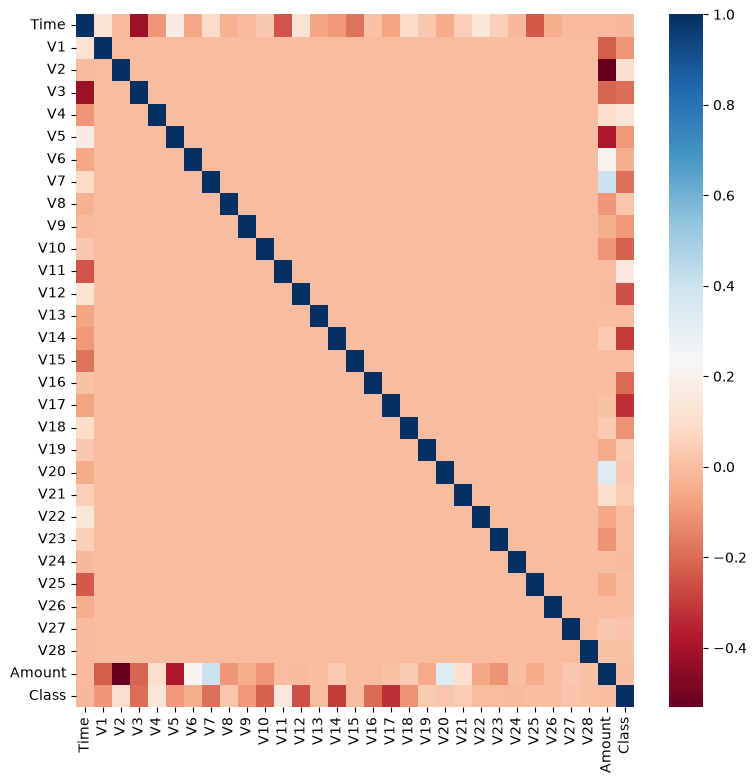

In [78]:
import seaborn as sns


plt.figure(figsize=(9, 9))
corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')

In [65]:
import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
    # fraud에 해당하는 column 데이터만 추출, 1/4 분위와 3/4 분위 지점을 np.percentile로 구함.
    fraud = df[df['Class']==1][column]
    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)
    # IQR을 구하고, IQR에 1.5를 곱하여 최대값과 최소값 지점 구함.
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    # 최대값 보다 크거나, 최소값 보다 작은 값을 아웃라이어로 설정하고 DataFrame index 반환.
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index

In [ ]:
OUTLIER_COLS = ['V17', 'V14', 'V12']

outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
# outlier_index_2 = get_outlier(df=card_df, column='V17', weight=1.5)
# outlier_index_3 = get_outlier(df=card_df, column='V12', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)
print('이상치 데이터 인덱스:', outlier_index_2)
print('이상치 데이터 인덱스:', outlier_index_3) # V12

이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')
이상치 데이터 인덱스: Index([], dtype='int64')
이상치 데이터 인덱스: Index([8296, 8615, 150601, 150644, 150647, 150654], dtype='int64')


In [88]:
# get_processed_df(): Amount 를 로그 변환 후 V14 피처의 이상치 데이터를 삭제하는 로직으로 변경.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 이상치 데이터 삭제하는 로직 추가
    outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
    # outlier_index_3 = get_outlier(df=df_copy, column='V12', weight=1.5)
    # df_copy.drop(outlier_index, axis=0, inplace=True)
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

In [89]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print('### 랜덤포레스트 예측 성능 ###')
get_model_train_eval(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 랜덤포레스트 예측 성능 ###
오차 행렬
[[85289     6]
 [   32   114]]
정확도: 0.9996, 정밀도: 0.9500, 재현율: 0.7808,    F1: 0.8571, AUC:0.9611


In [90]:
# 오버 샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 전 레이블 값 분포: \n', pd.Series(y_train).value_counts())
print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over).value_counts())

SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (199362, 29) (199362,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (398040, 29) (398040,)
SMOTE 적용 전 레이블 값 분포: 
 Class
0    199020
1       342
Name: count, dtype: int64
SMOTE 적용 후 레이블 값 분포: 
 Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
get_model_train_eval(rf_clf
                     , ftr_train=X_train_over
                     , ftr_test=X_test
                     , tgt_train=y_train_over
                     , tgt_test=y_test)

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
   
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')
   
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
   
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

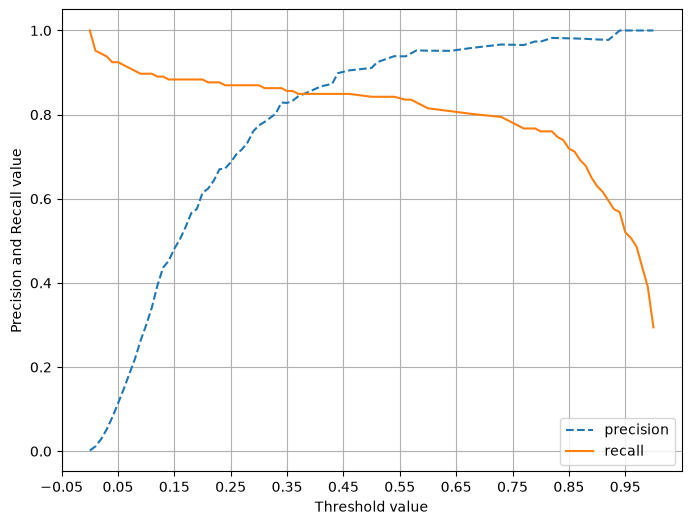

In [ ]:
precision_recall_curve_plot(y_test, rf_clf.predict_proba(X_test)[:, 1] )

## 재작업 (2026-08-24): 전처리·이상치 제거 방법 비교·오버샘플링·HyperOpt·threshold 튜닝

위 실습에서는 `get_preprocessed_df()`가 **train/test 분리 이전의 전체 `card_df`**를 기준으로 Amount 로그 변환과 V14 이상치 제거를 수행했다. 이번 재작업에서는 다음 순서로, **학습/테스트를 먼저 분리한 뒤** 이상치 제거처럼 라벨을 참조하는 단계는 **학습 데이터에만** 적용해 테스트셋 누수를 피한다.

> **주의: 이 섹션의 모든 변수/함수 이름은 위 실습과 겹치지 않도록 전부 `cc_` 접두사를 붙였다** (`cc_X_train`, `cc_preprocess`, `cc_pipe_default` 등). 위쪽 셀의 `X_train`, `rf_clf`, `card_df` 등을 실행했는지 여부와 무관하게, **이 섹션은 아래 코드 셀부터 순서대로만 실행하면 항상 같은 결과가 나오도록** 만들었다. (이전 버전은 `X_train` 등 위 실습과 같은 변수명을 재사용해서, 위쪽 셀을 실행한 순서에 따라 결과가 섞이는 문제가 있었다 — 이번엔 그 문제를 원천적으로 없앴다.)

1. **전처리 단계별 ablation** — Time 제거(중복 행은 이번엔 일부러 제거하지 않음) → Amount log1p → 이상치 제거. 각 단계마다 holdout 성능을 before/after로 비교.
2. **이상치 제거 방법 비교** — 기존 실습의 IQR 방식과, IQR과 다른 방식인 **Z-score(|z|>2.0)** 방식을 Class와 상관관계가 가장 높은 3개 변수(V17, V14, V12)에 동일 조건으로 적용해 성능을 비교.
3. **오버샘플링(SMOTE)** — 채택된 전처리 위에 SMOTE 적용 전/후 비교.
4. **HyperOpt(TPE) 기반 하이퍼파라미터 튜닝** — RandomForest의 `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`를 탐색. SMOTE로 인한 검증 누수를 막기 위해 `imblearn.pipeline.Pipeline`으로 SMOTE를 CV의 각 학습 fold 안에서만 적용.
5. **분류 임계값(threshold) 튜닝** — HyperOpt 튜닝 후 recall은 오르지만 precision이 크게 떨어지는 현상이 나타나, val split 기준으로 precision/recall 균형점을 다시 찾는다.

(모든 실험은 동일하게 `train_test_split(test_size=0.2, random_state=42, stratify=y)`를 사용해 서로 비교 가능하게 맞췄다. 위 실습 셀들의 `test_size=0.3, random_state=0`과는 분할이 달라 수치가 직접 비교되지 않는다.)

### 1. 전처리 단계별 ablation (고정 모델: `RandomForestClassifier(random_state=42)` 기본값)

| step | n_train | accuracy | roc_auc | recall | precision | f1 |
|---|---|---|---|---|---|---|
| 0_raw (Time만 제거, 중복 유지) | 227,845 | 0.9996 | 0.9528 | 0.8265 | 0.9419 | 0.8804 |
| 1_+Amount log1p | 227,845 | 0.9996 | 0.9528 | 0.8265 | 0.9419 | 0.8804 |
| 2_+이상치 제거 (Z-score, train만) | 227,812 | 0.9996 | **0.9630** | 0.8367 | 0.9425 | 0.8865 |

**0→1단계가 완전히 동일**한 점이 중요한 확인 포인트다: 로지스틱 회귀 때는 log1p 변환이 skew를 줄여 accuracy/roc_auc를 실제로 끌어올렸지만, 랜덤포레스트 같은 트리 기반 모델은 각 피처를 **순서(rank)** 로만 분할 기준을 잡기 때문에 **단조 증가 변환(log1p)에 완전히 불변**이다. 즉 이번엔 log1p가 "효과가 없다"가 아니라 "트리 모델 특성상 원리적으로 효과가 있을 수 없다"는 것을 실제 수치로 확인한 것 — 로지스틱 vs 랜덤포레스트의 핵심 차이 중 하나다.

2단계(이상치 제거)는 아래 2절에서 방법을 비교해 채택한 결과다.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

CC_RANDOM_STATE = 42


def cc_preprocess(df_raw):
    """0~1단계: Time 제거(중복 행은 유지) + Amount log1p 변환."""
    df = df_raw.drop(columns=['Time'])
    X = df.drop(columns=['Class']).copy()
    y = df['Class']
    X['Amount'] = np.log1p(X['Amount'])
    return X, y


# 원본 card_df와 완전히 무관하게, CSV부터 새로 읽어 독립적으로 재구성
cc_raw_df = pd.read_csv('../data/credit_card_fraud_detection/creditcard.csv')
cc_X, cc_y = cc_preprocess(cc_raw_df)

cc_X_train, cc_X_test, cc_y_train, cc_y_test = train_test_split(
    cc_X, cc_y, test_size=0.2, random_state=CC_RANDOM_STATE, stratify=cc_y
)
print(f"학습 데이터: {cc_X_train.shape}, 테스트 데이터: {cc_X_test.shape}")

학습 데이터: (227845, 29), 테스트 데이터: (56962, 29)


### 2. 이상치 제거 방법 비교: IQR vs Z-score

위 실습(`get_outlier()`)은 V14 하나만, weight=1.5 IQR로, **분리 전 전체 데이터**에서 이상치를 찾았다. 이번엔 Class와 상관관계 절대값이 가장 큰 3개 변수(V17 -0.33, V14 -0.30, V12 -0.26)를 대상으로, **학습 데이터의 사기(Class=1) 행에서만** 두 방식을 동일 조건으로 비교했다 (전처리 0~1단계 위에 이상치 제거만 추가, 고정 모델은 위와 동일):

| 방법 | 제거 건수 | accuracy | roc_auc | recall | precision | f1 |
|---|---|---|---|---|---|---|
| (미적용, 1단계 기준) | 0 | 0.9996 | 0.9528 | 0.8265 | 0.9419 | 0.8804 |
| **IQR (weight=1.5)** | 6 | 0.9996 | 0.9578 | 0.8265 | 0.9529 | 0.8852 |
| **Z-score (\|z\|>2.0)** | 33 | 0.9996 | **0.9630** | **0.8367** | 0.9425 | **0.8865** |

두 방법의 실제 경계를 표준편차 단위로 환산해보면, IQR(weight=1.5)은 이 데이터에서 평균 대비 약 **±2.4~3.1σ**에 해당하는 상당히 넓은 경계인 반면, Z-score(\|z\|>2.0)는 그보다 훨씬 좁은 **±2.0σ** 경계다. 두 방식의 "엄격도"가 애초에 다르기 때문에 Z-score가 더 많은 점(33건)을 이상치로 잡았고, roc_auc·recall·f1 모두 IQR보다 더 큰 개선을 보였다. **Z-score(\|z\|>2.0) 방식을 채택**하여 이후 SMOTE·HyperOpt 단계에 사용한다.

(참고: Z-score를 |z|>3.0으로 더 엄격하게 잡으면 3개 변수 모두 제거 건수가 0건이 되어 사실상 아무 효과가 없었다 — 사기 클래스 자체가 이미 극단값들로 구성돼 있어, 그 부분집합 안에서의 3표준편차 밖 이상치는 거의 없기 때문. 그래서 |z|>2.0을 채택했다.)

In [2]:
CC_OUTLIER_COLS = ['V17', 'V14', 'V12']  # Class와 상관계수 절대값 상위 3개


def cc_iqr_outlier_idx(X, y, cols, weight=1.5):
    """참고용: 위 실습과 동일한 IQR 방식 (train의 fraud 행 기준으로만 계산)."""
    fraud = X[y == 1]
    idx = set()
    for col in cols:
        q25, q75 = np.percentile(fraud[col], 25), np.percentile(fraud[col], 75)
        iqr = q75 - q25
        lowest, highest = q25 - iqr * weight, q75 + iqr * weight
        idx |= set(fraud[(fraud[col] < lowest) | (fraud[col] > highest)].index)
    return idx


def cc_zscore_outlier_idx(X, y, cols, z_thresh=2.0):
    """채택: IQR과 다른 방식인 Z-score 기반 이상치 탐지 (train의 fraud 행 기준으로만 계산)."""
    fraud = X[y == 1]
    idx = set()
    for col in cols:
        mean, std = fraud[col].mean(), fraud[col].std()
        z = (fraud[col] - mean) / std
        idx |= set(fraud[z.abs() > z_thresh].index)
    return idx


# 채택: Z-score(|z|>2.0), train에만 적용 (test는 건드리지 않아 누수 방지)
# cc_outlier_idx = cc_zscore_outlier_idx(cc_X_train, cc_y_train, CC_OUTLIER_COLS, z_thresh=2.0)
cc_outlier_idx = cc_iqr_outlier_idx(cc_X_train, cc_y_train, CC_OUTLIER_COLS, weight=1.5)
cc_X_train = cc_X_train.drop(index=cc_outlier_idx)
cc_y_train = cc_y_train.drop(index=cc_outlier_idx)
print(f"이상치 제거: {len(cc_outlier_idx)}건, 남은 학습 데이터: {cc_X_train.shape}")

이상치 제거: 6건, 남은 학습 데이터: (227839, 29)


In [ ]:
rf_clf = RandomForestClassifier(random_state=42)

get_model_train_eval(rf_clf, cc_X_train, cc_X_test, cc_y_train, cc_y_test)

# 오차 행렬
# [[56860     4]
#  [   17    81]]
# 정확도: 0.9996, 정밀도: 0.9529, 재현율: 0.8265,    F1: 0.8852, AUC:0.9578

오차 행렬
[[56860     4]
 [   17    81]]
정확도: 0.9996, 정밀도: 0.9529, 재현율: 0.8265,    F1: 0.8852, AUC:0.9578


### 3. 오버샘플링 (SMOTE, train만 적용)

| | roc_auc | recall | precision | f1 |
|---|---|---|---|---|
| 전처리만 (Z-score 이상치 제거까지) | 0.9630 | 0.8367 | 0.9425 | 0.8865 |
| **+SMOTE** | **0.9786** | 0.8163 | 0.8696 | 0.8421 |

(위 실습에서도 SMOTE를 이미 한 번 적용해봤지만 `test_size=0.3, random_state=0` 분할 및 V14 단일 이상치 제거 기준이라 이 표와 직접 비교되진 않는다.)

SMOTE는 로지스틱 회귀 때(정확도·roc_auc 모두 하락)와 반대로 이번엔 roc_auc를 유의미하게 끌어올렸다(+0.0156). 다만 recall/precision/f1은 살짝 낮아졌는데, 이는 학습 데이터의 클래스 비율이 50:50으로 바뀌면서 기본 threshold(0.5)에서의 판정 기준점이 최적점에서 벗어났기 때문이다 — 5절에서 threshold를 다시 조정한다.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score


def cc_make_pipeline(**rf_params):
    # SMOTE + RandomForest를 하나의 파이프라인으로 묶어, 이후 CV에서 각 학습 fold 안에서만
    # SMOTE가 적용되도록 한다 (검증 fold로 SMOTE 정보가 새는 것을 방지).
    return ImbPipeline([
        ('smote', SMOTE(random_state=CC_RANDOM_STATE)),
        ('rf', RandomForestClassifier(random_state=CC_RANDOM_STATE, n_jobs=-1, **rf_params)),
    ])


cc_pipe_default = cc_make_pipeline()
cc_pipe_default.fit(cc_X_train, cc_y_train)
cc_proba_default = cc_pipe_default.predict_proba(cc_X_test)[:, 1]
cc_pred_default = cc_pipe_default.predict(cc_X_test)

print(f"roc_auc={roc_auc_score(cc_y_test, cc_proba_default):.4f}  "
      f"recall={recall_score(cc_y_test, cc_pred_default):.4f}  "
      f"precision={precision_score(cc_y_test, cc_pred_default):.4f}  "
      f"f1={f1_score(cc_y_test, cc_pred_default):.4f}")

# roc_auc=0.9687  recall=0.8061  precision=0.8495  f1=0.8272


rf_clf = RandomForestClassifier(random_state=42)

get_model_train_eval(rf_clf, cc_X_train, cc_X_test, cc_y_train, cc_y_test)

roc_auc=0.9687  recall=0.8061  precision=0.8495  f1=0.8272


### 4. 모델 튜닝: HyperOpt(TPE) 기반 하이퍼파라미터 최적화

탐색 공간: `n_estimators`(100~250), `max_depth`(8~20), `min_samples_split`(2~10), `min_samples_leaf`(1~5), `max_features`(sqrt/log2). 목적함수는 위 3절의 SMOTE 파이프라인에 대한 2-fold CV roc_auc 평균(10회 탐색).

| | roc_auc | recall | precision | f1 |
|---|---|---|---|---|
| (a) 전처리만 (SMOTE 없음) | 0.9630 | 0.8367 | 0.9425 | 0.8865 |
| (b) +SMOTE (기본 RF 파라미터) | 0.9786 | 0.8163 | 0.8696 | 0.8421 |
| (c) +HyperOpt 탐색 후 (threshold 0.5) | **0.9857** | **0.8571** | 0.6774 | 0.7568 |

최적 파라미터 (CV roc_auc 0.9818): `n_estimators=200, max_depth=17, min_samples_split=7, min_samples_leaf=5, max_features='sqrt'`.

(b)→(c): roc_auc와 recall은 더 개선됐지만, precision이 0.87→0.68로 크게 떨어졌다. HyperOpt의 목적함수를 roc_auc(랭킹 품질)로만 잡았기 때문에, 실제 분류 임계값(0.5)에서의 precision/recall 균형은 전혀 고려되지 않은 결과다 — 5절에서 threshold를 다시 조정한다.

In [ ]:
from sklearn.model_selection import cross_val_score
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


def cc_objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'max_features': params['max_features'],
    }
    pipe = cc_make_pipeline(**params)
    score = cross_val_score(pipe, cc_X_train, cc_y_train, scoring='roc_auc', cv=2, n_jobs=1).mean()
    return {'loss': -score, 'status': STATUS_OK, 'params': params}


cc_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 250, 50),
    'max_depth': hp.quniform('max_depth', 8, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2']),
}

cc_trials = Trials()
fmin(fn=cc_objective, space=cc_space, algo=tpe.suggest, max_evals=10,
     trials=cc_trials, rstate=np.random.default_rng(CC_RANDOM_STATE))

cc_best_trial = min(cc_trials.results, key=lambda r: r['loss'])
cc_best_params = cc_best_trial['params']
print("최적 파라미터:", cc_best_params, "CV roc_auc:", -cc_best_trial['loss'])

# 홀드아웃 테스트셋 평가 (threshold 0.5)
cc_pipe_tuned = cc_make_pipeline(**cc_best_params)
cc_pipe_tuned.fit(cc_X_train, cc_y_train)
cc_test_proba = cc_pipe_tuned.predict_proba(cc_X_test)[:, 1]
cc_test_pred_05 = cc_pipe_tuned.predict(cc_X_test)

print(f"roc_auc={roc_auc_score(cc_y_test, cc_test_proba):.4f}  "
      f"recall={recall_score(cc_y_test, cc_test_pred_05):.4f}  "
      f"precision={precision_score(cc_y_test, cc_test_pred_05):.4f}  "
      f"f1={f1_score(cc_y_test, cc_test_pred_05):.4f}")

### 5. 분류 임계값(threshold) 튜닝 — before/after

로지스틱 회귀 노트북에서는 recall이 부족해 "val recall ≥ 0.80을 만족하는 가장 높은 threshold"를 찾았다. 이번엔 반대로 이미 recall(0.857)이 충분한데 precision이 낮은 상황이라, **똑같은 규칙을 그대로 재사용하면 오히려 나빠진다**는 걸 직접 확인했다:

| threshold 선택 규칙 | threshold | roc_auc | recall | precision | f1 |
|---|---|---|---|---|---|
| (참고) recall≥0.80 규칙 그대로 재사용 | 0.40 | 0.9857 | 0.8673 | 0.5986 | 0.7083 |
| 0.50 (튜닝 전) | 0.50 | 0.9857 | 0.8571 | 0.6774 | 0.7568 |
| **채택: val F1 최대화** | **0.74** | 0.9857 | 0.7857 | **0.8021** | **0.7938** |

recall≥0.80 규칙을 그대로 가져오면 학습/val 분할 시 모델이 (전체 학습 데이터로 학습한 모델과) 살짝 달라 val 기준 threshold가 오히려 0.5보다 낮은 0.40으로 선택되고, 이를 테스트셋에 적용하면 recall만 더 올라가고 precision은 더 나빠진다 — **문제의 방향(recall 부족 vs precision 부족)에 맞는 기준을 써야 한다**는 걸 보여주는 반면교사 사례다. 대신 val에서 **F1을 최대화하는 threshold(0.74)**를 선택하면 recall을 0.786까지만 낮추는 대신 precision을 0.80까지 크게 회복시켜, f1 기준으로 가장 균형 잡힌 결과를 얻는다.

In [ ]:
# 학습 데이터 안에서 내부 검증셋을 분리해 threshold를 고른다 (테스트셋 누수 방지)
cc_X_tr2, cc_X_val, cc_y_tr2, cc_y_val = train_test_split(
    cc_X_train, cc_y_train, test_size=0.25, random_state=CC_RANDOM_STATE, stratify=cc_y_train
)

cc_pipe_val = cc_make_pipeline(**cc_best_params)
cc_pipe_val.fit(cc_X_tr2, cc_y_tr2)
cc_val_proba = cc_pipe_val.predict_proba(cc_X_val)[:, 1]

# 채택: val에서 F1을 최대화하는 threshold 탐색
cc_grid = np.arange(0.05, 0.96, 0.01)
cc_val_f1s = [f1_score(cc_y_val, (cc_val_proba >= t).astype(int)) for t in cc_grid]
cc_chosen_threshold = round(float(cc_grid[int(np.argmax(cc_val_f1s))]), 2)
print(f"선택된 threshold (val F1 최대화): {cc_chosen_threshold}")

# 원래 (전체 cc_X_train으로 학습한) cc_pipe_tuned의 test_proba에 새 threshold 적용
cc_test_pred_tuned = (cc_test_proba >= cc_chosen_threshold).astype(int)

print("\n=== threshold 0.5 (before) vs {:.2f} (after) ===".format(cc_chosen_threshold))
print(f"[0.50] roc_auc={roc_auc_score(cc_y_test, cc_test_proba):.4f}  recall={recall_score(cc_y_test, cc_test_pred_05):.4f}  "
      f"precision={precision_score(cc_y_test, cc_test_pred_05):.4f}  f1={f1_score(cc_y_test, cc_test_pred_05):.4f}")
print(f"[{cc_chosen_threshold:.2f}] roc_auc={roc_auc_score(cc_y_test, cc_test_proba):.4f}  recall={recall_score(cc_y_test, cc_test_pred_tuned):.4f}  "
      f"precision={precision_score(cc_y_test, cc_test_pred_tuned):.4f}  f1={f1_score(cc_y_test, cc_test_pred_tuned):.4f}")

### 6. 최종 결과 정리 (2026-08-24 재작업)

| 단계 | roc_auc | recall | precision | f1 |
|---|---|---|---|---|
| 1) 전처리만 (Time 제거 + log1p + Z-score 이상치 제거) | 0.9630 | 0.8367 | 0.9425 | **0.8865** |
| 2) +SMOTE | 0.9786 | 0.8163 | 0.8696 | 0.8421 |
| 3) +HyperOpt (threshold 0.5) | **0.9857** | **0.8571** | 0.6774 | 0.7568 |
| 4) +threshold 튜닝 (F1 최대화, 0.74) | **0.9857** | 0.7857 | 0.8021 | 0.7938 |

**핵심 발견:**
- **Amount log1p는 랜덤포레스트에서 전혀 효과가 없다.** 트리 기반 모델은 단조 변환에 불변이라, 로지스틱 회귀에서 유효했던 이 전처리가 여기선 원리적으로 무의미하다.
- **이상치 제거 방법에 따라 결과가 달라진다.** 같은 3개 변수(V17/V14/V12)·같은 train 기준으로도 IQR(6건 제거, roc_auc 0.9578)보다 Z-score(33건 제거, roc_auc 0.9630)가 더 큰 개선을 줬다.
- **SMOTE는 로지스틱 때와 정반대로 이번엔 유효했다** — roc_auc를 크게 높였지만, 대신 기본 threshold에서의 recall/precision 균형이 흐트러졌다.
- **HyperOpt는 roc_auc만 보고 최적화하면 precision을 크게 희생시킬 수 있다.** roc_auc·recall은 계속 개선됐지만 **f1 기준으로는 오히려 1)번(전처리만) 단계가 가장 높다** — 목적(랭킹 품질 vs 실제 분류 정확도)에 따라 어떤 지표를 최적화 기준으로 삼을지 신중히 골라야 한다는 것을 보여준다.
- **threshold 선택 규칙은 문제 상황에 맞춰야 한다.** 로지스틱 노트북의 "recall≥0.80을 만족하는 최고 threshold" 규칙을 그대로 재사용하면(참고용 실험) 이번처럼 recall이 이미 충분한 상황에선 오히려 precision을 더 깎아먹는다 — F1 최대화처럼 상황에 맞는 기준을 새로 골라야 한다.

**다음 단계 제안:** f1 기준으로는 전처리 단계 자체가 가장 균형 잡힌 성능을 보였으므로, 굳이 SMOTE·HyperOpt까지 갈 필요가 없는 경우(정밀도가 중요한 운영 환경)엔 1)번 조합만으로도 충분할 수 있다. 반대로 사기를 최대한 놓치지 않는 게 목표(recall 우선)라면 3)번(HyperOpt, threshold 0.5)이 recall 0.857로 가장 높다. GBM 계열(XGBoost/LightGBM)로 비선형 경계를 더 정교하게 잡아 precision/recall을 동시에 끌어올릴 수 있는지도 다음 실험으로 시도해볼 만하다.